In [7]:
#1D - SOM for Snow-Depth Change Clustering
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

#sklearn
from sklearn.metrics import accuracy_score, classification_report, root_mean_squared_error, r2_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [8]:
#upload the data
df = pd.read_csv('data/input_df_SUMMmet.csv')  

#clean out rows with nan entries and columns that are completely nan
df = df.dropna(axis=1, how='all')
df = df.dropna()

#dropping irrelavant sites
sites_to_drop = ['PTSH', 'SPST', 'SR01', 'SR25', 'SR11']
df = df[~df['site.x'].isin(sites_to_drop)]

In [9]:
#build snow change target
threshold = 1e-6
y = pd.Series(3, index=df.index)   # default no-change
y[df['delta'] > threshold] = 1     # accumulation
y[df['delta'] < -threshold] = 2    # ablation
y = y.astype(int)

#build features as well
X = df.drop(columns=[
    'Unnamed: 0', 'date', 'site.x', 'site.y',
    'SNOD', 'delta', 'X'
])
# Convert to matrix
X = X.astype(float)

#scale and standardize features as well
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

#normalize
X = (X - X.min()) / (X.max() - X.min())
X_scaled = X.values

In [10]:
# --- 2D SOM implementation (simple, numpy) ---
class SOM2D:
    def __init__(self, height, width, n_features, lr=0.5, sigma=None, n_epochs=1000, random_state=None):
        self.height = height
        self.width = width
        self.n_nodes = height * width
        self.n_features = n_features
        self.lr0 = lr
        self.sigma0 = sigma if sigma is not None else max(height, width) / 2.0
        self.n_epochs = n_epochs
        self.rng = np.random.default_rng(random_state)
        # weights: (height, width, n_features)
        self.weights = self.rng.normal(loc=0.0, scale=0.1, size=(height, width, n_features))

        # precompute grid coordinates for efficiency
        r = np.arange(height)
        c = np.arange(width)
        self.grid_r, self.grid_c = np.meshgrid(r, c, indexing='ij')

    def _bmu(self, x):
        # compute BMU index (row, col)
        d = np.linalg.norm(self.weights - x[np.newaxis, np.newaxis, :], axis=2)
        bmu_idx = np.unravel_index(np.argmin(d), (self.height, self.width))
        return bmu_idx

    def _neighborhood(self, bmu_row, bmu_col, sigma):
        # squared distance from BMU for each node
        sqdist = (self.grid_r - bmu_row)**2 + (self.grid_c - bmu_col)**2
        return np.exp(-sqdist / (2 * sigma**2))  # shape (height, width)

    def fit(self, X):
        n = X.shape[0]
        for epoch in range(self.n_epochs):
            # decays
            lr = self.lr0 * np.exp(-epoch / self.n_epochs)
            sigma = self.sigma0 * np.exp(-epoch / self.n_epochs)

            # shuffle
            perm = self.rng.permutation(n)
            for idx in perm:
                x = X[idx]
                bmu_r, bmu_c = self._bmu(x)
                neigh = self._neighborhood(bmu_r, bmu_c, sigma)[:, :, np.newaxis]  # (h,w,1)
                # update weights (elementwise broadcasting)
                self.weights += lr * neigh * (x - self.weights)

    def predict_bmu(self, X):
        bmus = [self._bmu(x) for x in X]
        return np.array(bmus)  # shape (n, 2)

    def get_prototypes(self):
        return self.weights.reshape(-1, self.n_features)  # (h*w, n_features)

In [12]:
# --- U-matrix ---
def compute_u_matrix(weights):
    H, W, F = weights.shape
    u = np.zeros((H, W))
    for i in range(H):
        for j in range(W):
            neigh_vals = []
            for di in (-1,0,1):
                for dj in (-1,0,1):
                    if di==0 and dj==0: 
                        continue
                    ni, nj = i+di, j+dj
                    if 0 <= ni < H and 0 <= nj < W:
                        neigh_vals.append(np.linalg.norm(weights[i,j] - weights[ni,nj]))
            if neigh_vals:
                u[i,j] = np.mean(neigh_vals)
    return u

In [11]:
# X_scaled and y assumed available (your preproc)
H, W = 6, 6   # a 6x6 map (36 nodes) is a good starting point; tune it
som = SOM2D(height=H, width=W, n_features=X_scaled.shape[1], lr=0.5, sigma=max(H,W)/2, n_epochs=1200, random_state=42)

print("Training SOM (this may take a bit)...")
som.fit(X_scaled)

# --- compute BMUs for every sample ---
bmus = som.predict_bmu(X_scaled)  # array of shape (N,2)
bmu_flat = bmus[:,0]*W + bmus[:,1]  # convert to node index 0..H*W-1

# --- Build a dataframe for evaluation ---
eval_df = pd.DataFrame({
    'bmu_row': bmus[:,0],
    'bmu_col': bmus[:,1],
    'bmu_idx': bmu_flat,
    'true_class': y.values
})

Training SOM (this may take a bit)...


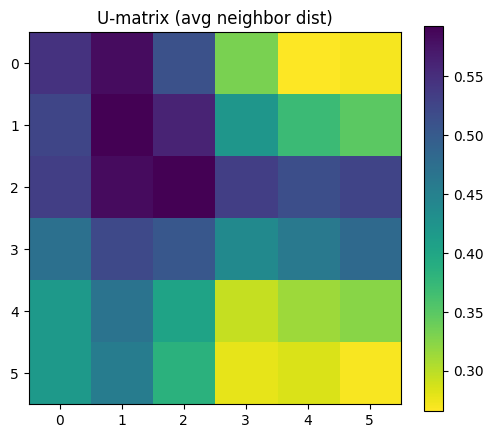

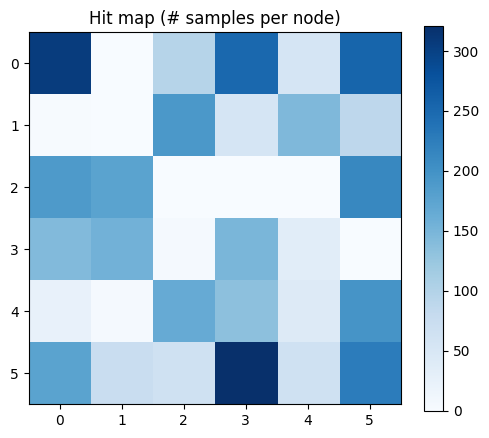

In [13]:
u = compute_u_matrix(som.weights)
plt.figure(figsize=(6,5))
plt.imshow(u, origin='upper', cmap='viridis_r')
plt.title('U-matrix (avg neighbor dist)')
plt.colorbar()
plt.show()

# --- Hit map (counts per node) ---
counts = eval_df['bmu_idx'].value_counts().sort_index()
counts2d = np.zeros((H*W,))
counts2d[counts.index.values] = counts.values
counts2d = counts2d.reshape(H,W)

plt.figure(figsize=(6,5))
plt.imshow(counts2d, origin='upper', cmap='Blues')
plt.title('Hit map (# samples per node)')
plt.colorbar()
plt.show()


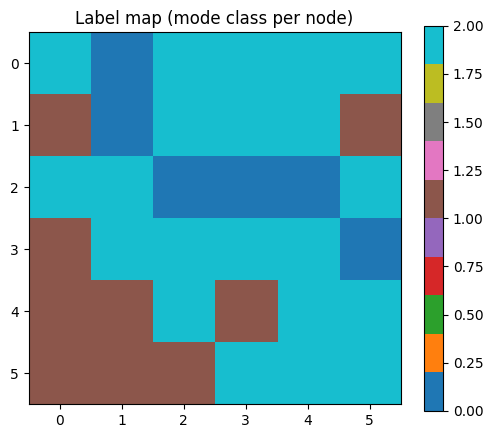

In [14]:
# --- Label map (majority vote per node) ---
node_to_mode = eval_df.groupby('bmu_idx')['true_class'].agg(lambda s: s.mode()[0])
# some nodes may not have any hits -> fill with 0
all_nodes = pd.Series(0, index=np.arange(H*W))
all_nodes.loc[node_to_mode.index] = node_to_mode.values
label_map_2d = all_nodes.values.reshape(H,W)

plt.figure(figsize=(6,5))
plt.imshow(label_map_2d, origin='upper', cmap='tab10')
plt.title('Label map (mode class per node)')
plt.colorbar()
plt.show()


In [15]:
# --- Evaluate method 1: node majority-vote predictions ---
pred_majority = np.array([all_nodes[idx] for idx in bmu_flat])  # predicted classes
print("Majority-vote mapping accuracy:", accuracy_score(y, pred_majority))
print(classification_report(y, pred_majority))
print("Confusion matrix:\n", confusion_matrix(y, pred_majority))

Majority-vote mapping accuracy: 0.5162581290645323
              precision    recall  f1-score   support

           1       0.42      0.22      0.29      1339
           2       0.54      0.87      0.66      2033
           3       0.00      0.00      0.00       626

    accuracy                           0.52      3998
   macro avg       0.32      0.36      0.32      3998
weighted avg       0.41      0.52      0.43      3998

Confusion matrix:
 [[ 296 1043    0]
 [ 265 1768    0]
 [ 149  477    0]]


c:\Users\Jack Klug\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Jack Klug\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Jack Klug\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

KMeans-on-prototypes mapping accuracy: 0.5162581290645323
              precision    recall  f1-score   support

           1       0.42      0.22      0.29      1339
           2       0.54      0.87      0.66      2033
           3       0.00      0.00      0.00       626

    accuracy                           0.52      3998
   macro avg       0.32      0.36      0.32      3998
weighted avg       0.41      0.52      0.43      3998

Confusion matrix:
 [[ 296 1043    0]
 [ 265 1768    0]
 [ 149  477    0]]


c:\Users\Jack Klug\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Jack Klug\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Jack Klug\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

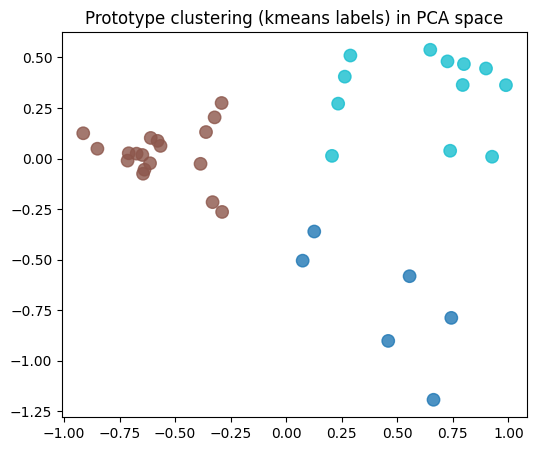

In [16]:
# --- Method 2: k-means on prototypes into 3 clusters ---
protos = som.get_prototypes()  # shape (H*W, features)
kmeans = KMeans(n_clusters=3, random_state=42).fit(protos)
node_kmeans_label = kmeans.labels_  # for each node 0..H*W-1
pred_kmeans = node_kmeans_label[bmu_flat]  # predicted cluster (0..2)
# kmeans clusters are unlabeled; map clusters to your class labels by majority vote
node_to_class_via_kmeans = {}
for node_id in range(H*W):
    cl = node_kmeans_label[node_id]
    # get true labels for samples mapped to this node
    samples_here = eval_df[eval_df['bmu_idx']==node_id]['true_class']
    if len(samples_here)>0:
        # majority true class among node's samples
        node_to_class_via_kmeans[node_id] = samples_here.mode()[0]
    else:
        # if no samples, assign the modal class among all samples for nodes in that cluster
        node_to_class_via_kmeans[node_id] = None

# convert kmeans cluster predictions into class labels for samples
pred_kmeans_classes = []

for nid, cluster_label in zip(bmu_flat, node_kmeans_label[bmu_flat]):
    mapped_class = node_to_class_via_kmeans.get(nid, None)
    if mapped_class is None:
        # fallback: assign the majority class of that kmeans cluster across all nodes
        nodes_in_cluster = np.where(node_kmeans_label == cluster_label)[0]
        # gather true labels of samples falling on those nodes
        samples = eval_df[eval_df['bmu_idx'].isin(nodes_in_cluster)]['true_class']
        mapped_class = samples.mode()[0] if len(samples)>0 else 2  # fallback to majority class overall
    pred_kmeans_classes.append(mapped_class)

pred_kmeans_classes = np.array(pred_kmeans_classes, dtype=int)
print("KMeans-on-prototypes mapping accuracy:", accuracy_score(y, pred_kmeans_classes))
print(classification_report(y, pred_kmeans_classes))
print("Confusion matrix:\n", confusion_matrix(y, pred_kmeans_classes))

# --- Optional: PCA projection of prototypes and nodes for quick visual check ---
pca = PCA(n_components=2)
proto2d = pca.fit_transform(protos)
plt.figure(figsize=(6,5))
plt.scatter(proto2d[:,0], proto2d[:,1], c=node_kmeans_label, cmap='tab10', s=80, alpha=0.8)
plt.title('Prototype clustering (kmeans labels) in PCA space')
plt.show()